In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import copy

In [2]:
data = np.load("halo_features_2D_31-2.npz")

n_subs      = data["n_subs"]
sigma_v     = data["sigma_v"]
tme_masses  = data["tme_masses"]
true_masses = data["true_masses"]
halo_ids    = data["halo_ids"]
v_means     = data["v_means"]

print("Loaded features:", n_subs.shape, sigma_v.shape)

Loaded features: (13248,) (13248,)


In [3]:
print("NaN in tme_masses:", np.isnan(tme_masses).sum())
print("NaN in true_masses:", np.isnan(true_masses).sum())
print("NaN in sigma_v:", np.isnan(sigma_v).sum())
print("NaN in n_subs:", np.isnan(n_subs).sum())

print("<=0 in tme_masses:", np.sum(tme_masses <= 0))
print("<=0 in true_masses:", np.sum(true_masses <= 0))
print("<=0 in n_subs:", np.sum(n_subs <= 0))

print("inf in tme_masses:", np.isinf(tme_masses).sum())
print("inf in true_masses:", np.isinf(true_masses).sum())
print("inf in sigma_v:", np.isinf(sigma_v).sum())

print("v_means shape:", np.shape(v_means))
print("v_means dtype:", getattr(v_means, "dtype", type(v_means)))
print("first element:", v_means[0])

NaN in tme_masses: 0
NaN in true_masses: 0
NaN in sigma_v: 0
NaN in n_subs: 0
<=0 in tme_masses: 0
<=0 in true_masses: 0
<=0 in n_subs: 0
inf in tme_masses: 0
inf in true_masses: 0
inf in sigma_v: 0
v_means shape: (13248,)
v_means dtype: float64
first element: -168.61496292414813


In [4]:
t_U = 13.8                        # Gyr
G_cosmo = 4.498638185699749e-15   # Mpc^3 / (Msun Gyr^2)
R0_pme = ((8.0 * G_cosmo * tme_masses * (t_U**2)) / (np.pi**2))**(1/3)

#v_mean_mag = np.linalg.norm(v_means, axis=1)
v_mean_mag = np.abs(v_means)
n_subs_safe = np.maximum(n_subs.astype(float), 2.0)        # make sure n-1 >=1

# sigma_by_sqrtN      = sigma_v / np.sqrt(n_subs_safe)                    
# sigma_by_sqrtN_unbiased = sigma_v / np.sqrt(n_subs_safe - 1.0)          
# sigma_by_sqrtN = np.clip(sigma_by_sqrtN, None, 500)          
# sigma_by_sqrtN_unbiased = np.clip(sigma_by_sqrtN_unbiased, None, 500)

X = np.vstack([
    np.log10(n_subs),
    np.log10(R0_pme),
    np.log10(tme_masses),
    #R_mags,
    sigma_v,
    v_mean_mag,
    #sigma_v / np.sqrt(n_subs - 1),          
]).T.astype(np.float32)

# delta = log10(M_true) - log10(M_PME)
y = (np.log10(true_masses) - np.log10(tme_masses)).astype(np.float32).reshape(-1, 1)
#y = np.log10(true_masses).astype(np.float32).reshape(-1, 1)

X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X_std_safe = np.where(X_std < 1e-6, 1.0, X_std)
X = (X - X_mean) / X_std_safe


# train/ test
indices = np.arange(len(X))
np.random.seed(40)
np.random.shuffle(indices)

train_size = int(0.8 * len(X))  # 80% train set
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, y_train = torch.tensor(X[train_idx]), torch.tensor(y[train_idx])
X_test,  y_test  = torch.tensor(X[test_idx]),  torch.tensor(y[test_idx])

print("Train set:", X_train.shape, y_train.shape)
print("Test  set:", X_test.shape, y_test.shape)


# 2. MLP (Dropout)
# =======================

class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(0),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
        )

    def forward(self, x):
        return x + self.block(x)   


class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(5, 256),
            nn.LayerNorm(256),
            nn.GELU(),
        )

        self.layers = nn.Sequential(
            ResidualBlock(256),
            ResidualBlock(256),
            ResidualBlock(256),     
        )

        self.output_proj = nn.Sequential(
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.layers(x)
        return self.output_proj(x)


model = MLP()
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# TRAIN
best_loss = np.inf
patience, patience_counter = 10, 0

from torch.utils.data import TensorDataset, DataLoader

# Dataset
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)


# mini-batch

for epoch in range(50):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = loss_fn(y_pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    
    # TEST LOSS
    model.eval()
    test_losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            y_pred = model(xb)
            test_losses.append(loss_fn(y_pred, yb).item())
    
    mean_train_loss = np.mean(train_losses)
    mean_test_loss = np.mean(test_losses)

    if (epoch+1) % 1 == 0:
        print(f"Epoch {epoch+1}, Train Loss {mean_train_loss:.4f}, Test Loss {mean_test_loss:.4f}")


    if mean_test_loss < best_loss:
        best_loss = mean_test_loss
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break



# 4. CORRECTION
model.eval()
with torch.no_grad():
    delta_pred = model(X_test).numpy().flatten()   
    delta_true = y_test.numpy().flatten()          
    # delta_pred = model(X_test).numpy().flatten()
    # delta_true = np.log10(true_masses[test_idx])


# MASS AFTER CORR
log_M_PME = np.log10(tme_masses[test_idx])
log_M_corr = log_M_PME + delta_pred
log_M_true = np.log10(true_masses[test_idx])

# =======================
# 5. Evaluation
# =======================
r2_corr = 1 - np.sum((log_M_true - log_M_corr)**2) / np.sum((log_M_true - np.mean(log_M_true))**2)
mae_corr = np.mean(np.abs(log_M_true - log_M_corr))

resid_before = np.log10(tme_masses[test_idx]) - log_M_true
resid_after  = log_M_corr - log_M_true

var_before = np.var(resid_before)
var_after  = np.var(resid_after)

print(f"R^2 after correction = {r2_corr:.4f}")
print(f"MAE in log10(M) after correction = {mae_corr:.4f}")
print(f"Residual variance before correction = {var_before:.4e}")
print(f"Residual variance after  correction = {var_after:.4e}")

std_before = np.std(resid_before)
std_after  = np.std(resid_after)

print(f"Residual std before correction = {std_before:.4f}")
print(f"Residual std after  correction = {std_after:.4f}")


# Permutation Importance, all features
# The column order of X must match this list exactly
features = [
    "log10(N_subs)",
    "np.log10(R0_pme)",
    "log10(M_TME)",
    # "R_mags",
    "sigma_v",
    "v_mean_mag",
]

assert X_test.shape[1] == len(features), f"X_test has {X_test.shape[1]} features, but features list has {len(features)}"

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot

# baseline R²
baseline_r2 = r2_corr

# number of permutation repeats: larger → more stable estimates (5–20 is typical)
n_repeats = 10
rng = np.random.default_rng(123)

X_test_np = X_test.detach().cpu().numpy()

importances_mean = []
importances_std  = []

for i in range(X_test_np.shape[1]):
    drops = []
    for _ in range(n_repeats):
        X_perm = X_test_np.copy()
        perm_idx = rng.permutation(X_perm.shape[0])
        X_perm[:, i] = X_perm[perm_idx, i]  # shuffle only the i-th column

        with torch.no_grad():
            delta_perm = model(torch.tensor(X_perm, dtype=torch.float32)).cpu().numpy().flatten()

        log_M_corr_perm = log_M_PME + delta_perm
        r2_perm = r2_score(log_M_true, log_M_corr_perm)
        drops.append(baseline_r2 - r2_perm)

    importances_mean.append(np.mean(drops))
    importances_std.append(np.std(drops))

importances_mean = np.array(importances_mean)
importances_std  = np.array(importances_std)

# sort by importance (larger R² drop → more important)
order = np.argsort(importances_mean)[::-1]

print("\nFeature importances (Permutation, R² drop):")
for idx in order:
    print(f"{features[idx]:<15s}: {importances_mean[idx]:.6f} ± {importances_std[idx]:.6f}")


# ensure numpy float arrays
X_mean_np = np.asarray(X_mean, dtype=np.float32)
X_std_np  = np.asarray(X_std,  dtype=np.float32)

np.savez("scaler_and_model_2D.31.npz", X_mean=X_mean_np, X_std=X_std_np)
torch.save(model.state_dict(), "mlp_pme_model_2D.31.pt")
print("MODEL SAVED.")

Train set: torch.Size([10598, 5]) torch.Size([10598, 1])
Test  set: torch.Size([2650, 5]) torch.Size([2650, 1])
Epoch 1, Train Loss 0.0169, Test Loss 0.0115
Epoch 2, Train Loss 0.0116, Test Loss 0.0119
Epoch 3, Train Loss 0.0116, Test Loss 0.0115
Epoch 4, Train Loss 0.0114, Test Loss 0.0115
Epoch 5, Train Loss 0.0114, Test Loss 0.0114
Epoch 6, Train Loss 0.0116, Test Loss 0.0130
Epoch 7, Train Loss 0.0114, Test Loss 0.0115
Epoch 8, Train Loss 0.0114, Test Loss 0.0114
Epoch 9, Train Loss 0.0113, Test Loss 0.0120
Epoch 10, Train Loss 0.0114, Test Loss 0.0115
Epoch 11, Train Loss 0.0112, Test Loss 0.0115
Epoch 12, Train Loss 0.0115, Test Loss 0.0116
Epoch 13, Train Loss 0.0114, Test Loss 0.0114
Epoch 14, Train Loss 0.0113, Test Loss 0.0122
Epoch 15, Train Loss 0.0112, Test Loss 0.0117
Early stopping at epoch 15
R^2 after correction = 0.9339
MAE in log10(M) after correction = 0.0862
Residual variance before correction = 1.2944e-02
Residual variance after  correction = 1.1550e-02
Residual s


Feature importances (Permutation, R² drop):
sigma_v        : 0.026114 ± 0.001039
np.log10(R0_pme): 0.015062 ± 0.000870
log10(M_TME)   : 0.007916 ± 0.000368
v_mean_mag     : 0.000859 ± 0.000476
log10(N_subs)  : 0.000000 ± 0.000000


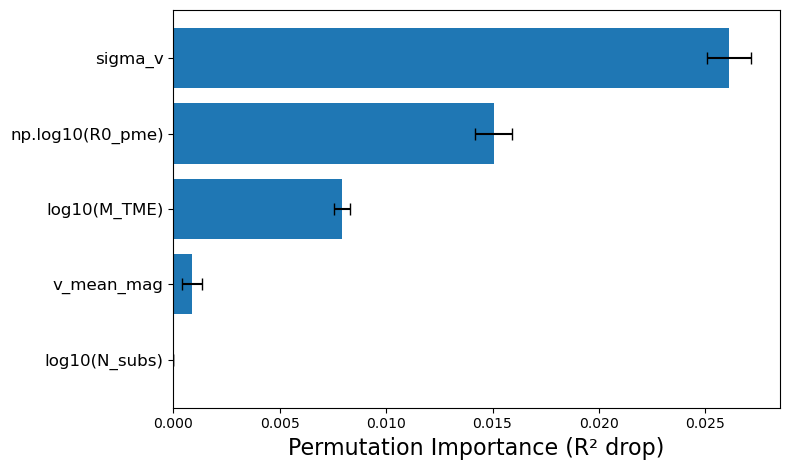

In [5]:
# importance
order = np.argsort(importances_mean)[::-1]
feat_sorted = [features[i] for i in order]
mean_sorted = importances_mean[order]
std_sorted  = importances_std[order]

print("\nFeature importances (Permutation, R² drop):")
for f, m, s in zip(feat_sorted, mean_sorted, std_sorted):
    print(f"{f:<15s}: {m:.6f} ± {s:.6f}")

plt.figure(figsize=(8, 4.8))
y_pos = np.arange(len(feat_sorted))
plt.barh(y_pos, mean_sorted, xerr=std_sorted, capsize=4)
plt.yticks(y_pos, feat_sorted,fontsize=12)
plt.gca().invert_yaxis() 
plt.xlabel("Permutation Importance (R² drop)",fontsize=16)
#plt.title("Feature Importance (Permutation)",fontsize=16)
plt.tight_layout()
plt.savefig("ph.png", bbox_inches="tight")
plt.show()

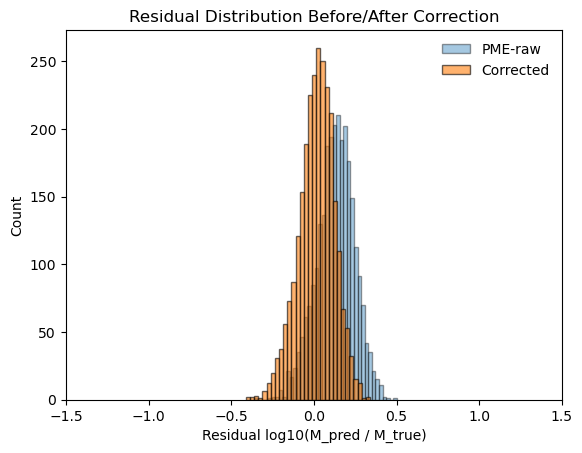

In [6]:
# (b) residual
plt.figure()
plt.hist(np.log10(tme_masses[test_idx]+1) - log_M_true, 
         bins=40, alpha=0.4, label="PME-raw", edgecolor="black")
plt.hist(log_M_corr - log_M_true, 
         bins=30, alpha=0.6, label="Corrected", edgecolor="black")
plt.xlabel("Residual log10(M_pred / M_true)")
plt.ylabel("Count")
plt.legend(frameon=False)
plt.title("Residual Distribution Before/After Correction")
plt.xlim(-1.5, 1.5)
plt.show()

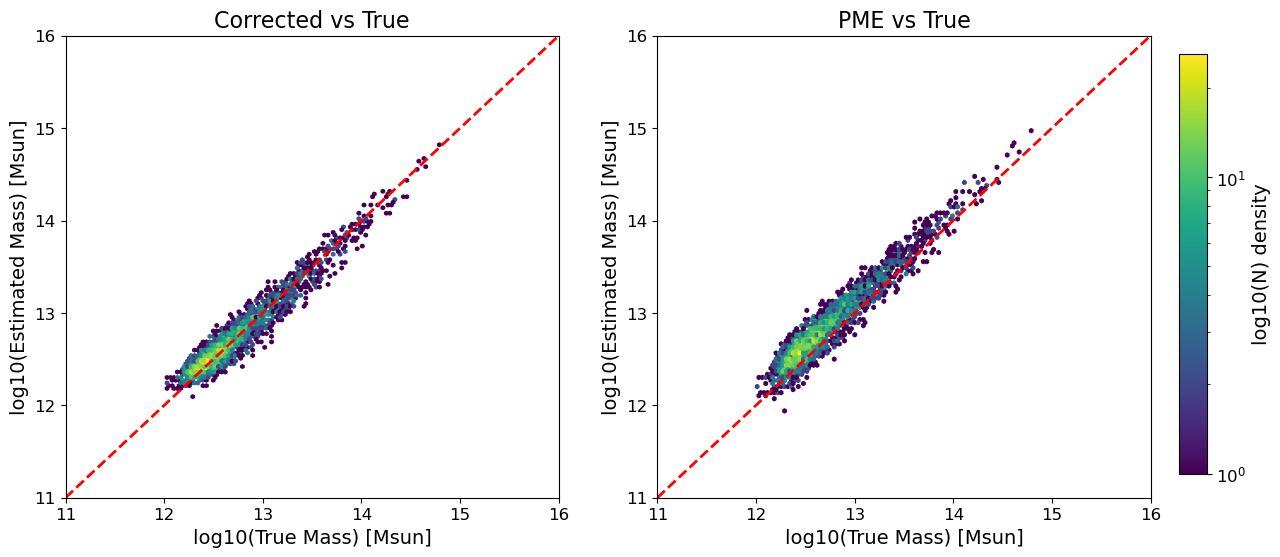

2650

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# (a) Corrected vs True
hb1 = axes[0].hexbin(np.log10(true_masses[test_idx]), 
                     log_M_corr,
                     gridsize=80, cmap='viridis', bins='log')
lims = [11, 16]
axes[0].plot(lims, lims, "r--", lw=2)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("log10(True Mass) [Msun]", fontsize=14)
axes[0].set_ylabel("log10(Estimated Mass) [Msun]", fontsize=14)
axes[0].set_title("Corrected vs True", fontsize=16)
axes[0].tick_params(labelsize=12)

# (b) PME vs True
log_M_true = np.log10(true_masses[test_idx] + 1)
log_M_pme  = np.log10(tme_masses[test_idx] + 1)

hb2 = axes[1].hexbin(log_M_true, log_M_pme,
                     gridsize=80, cmap='viridis', bins='log')
axes[1].plot(lims, lims, "r--", lw=2)
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_xlabel("log10(True Mass) [Msun]", fontsize=14)
axes[1].set_ylabel("log10(Estimated Mass) [Msun]", fontsize=14)
axes[1].set_title("PME vs True", fontsize=16)
axes[1].tick_params(labelsize=12)

# colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cb = fig.colorbar(hb2, cax=cbar_ax)
cb.set_label("log10(N) density", fontsize=14)
cb.ax.tick_params(labelsize=12)

plt.subplots_adjust(right=0.9) 
plt.savefig("MLP-8.pdf")
plt.show()

len(log_M_pme)